# Eksperyment 4: Analiza halucynacji i błędów semantycznych

**Przedmiot:** ADOM  
**Metoda:** Show and Tell - automatyczne opisywanie obrazów  
**Data realizacji:** Maj 2026

---

## Cel eksperymentu

Systematyczna identyfikacja przypadków w których model opisuje obiekty
nieobecne na zdjęciu lub przypisuje im nieprawidłowe cechy - halucynacje.

**Hipoteza:** Model częściej halucynuje przy obiektach rzadkich w zbiorze
treningowym MS COCO - zamiast nich generuje wizualnie podobne, ale częstsze obiekty
(*semantic fallback*).

---

## Metodologia

Eksperyment używa 30 własnych obrazów z 6 klas najrzadszych obiektów.

| Klasa | Częstotliwość w COCO train |
|-------|---------------------------|
| `handbag` | 58 |
| `toaster` | 221 |
| `carrot` | 342 |
| `backpack` | 503 |
| `spoon` | 513 |
| `toothbrush` | 629 |

Dla każdego obrazu model generuje opis, który jest następnie ręcznie
klasyfikowany do jednej z kategorii błędów według poniższego protokołu.

---

## Protokół anotacji

| Kategoria | Opis |
|-----------|------|
| `a` | **Halucynacja** - model opisuje obiekt którego nie ma na zdjęciu |
| `b` | **Błędny atrybut** - obiekt rozpoznany, ale błędna cecha (np. czynność, kolor) |
| `c` | **Błąd strukturalny** - opis niespójny gramatycznie lub powtarzający słowa |
| `d` | **Poprawny opis** - semantycznie zgodny z obrazem |
| `e` | **Poprawna generalizacja** - użycie synonimu lub hiperonimu (np. *luggage* zamiast *handbag*) |

---

## Lista kategorii obiektów MS COCO (80 klas)

Pełna lista etykiet: [https://github.com/amikelive/coco-labels/blob/master/coco-labels-2014_2017.txt](https://github.com/amikelive/coco-labels/blob/master/coco-labels-2014_2017.txt)

## Krok 1: Statystyki częstotliwości obiektów w zbiorze treningowym

Obliczamy ile obrazów treningowych zawiera każdy z badanych obiektów
w opisach referencyjnych. To pozwoli później powiązać rzadkość obiektu
z częstością halucynacji.

In [2]:
import json
import pandas as pd
from collections import Counter
import pandas as pd
import sys
import os
import json
import torch

# Path alignment
sys.path.append(os.path.abspath(os.path.join('..')))
from caption import caption_image_beam_search

# File paths
DATASET_PATH = '../dataset/caption_datasets/dataset_coco.json'

# Load Word Map
word_map_path = '../dataset/WORDMAP_coco_5_cap_per_img_5_min_word_freq.json'
with open(word_map_path, 'r') as j:
    word_map = json.load(j)
rev_word_map = {v: k for k, v in word_map.items()}

# Device & Model Loading
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint_path = '../checkpoints/BEST_checkpoint_coco_5_cap_per_img_5_min_word_freq.pth.tar'

checkpoint = torch.load(checkpoint_path, map_location=str(device), weights_only=False)
decoder = checkpoint['decoder'].to(device).eval()
encoder = checkpoint['encoder'].to(device).eval()

# COCO categories
# https://github.com/amikelive/coco-labels/blob/master/coco-labels-2014_2017.txt
COCO_OBJECTS = {
    'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant',
    'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase',
    'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
    'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork',
    'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli',
    'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant',
    'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 
    'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
}

def get_filtered_training_stats():
    # Load raw captions
    with open(DATASET_PATH, 'r') as j:
        data = json.load(j)
    
    # Extract only tokens that are in our COCO_OBJECTS list
    train_tokens = [
        word 
        for img in data['images'] if img['split'] == 'train'
        for sentence in img['sentences']
        for word in sentence['tokens']
        if word in COCO_OBJECTS
    ]
    
    stats = Counter(train_tokens)
    df = pd.DataFrame(stats.items(), columns=['Object', 'Frequency']).sort_values('Frequency')
    
    return df

# Execute
df_obj_stats = get_filtered_training_stats()

print("--- Rarest Objects (Hardest to Detect) ---")
print(df_obj_stats.head(10).to_string(index=False))

print("\n--- Most Frequent Objects (Highest Bias) ---")
print(df_obj_stats.tail(10).to_string(index=False))

--- Rarest Objects (Hardest to Detect) ---
    Object  Frequency
   handbag         58
   toaster        221
    carrot        342
  backpack        503
     spoon        513
toothbrush        629
     donut        884
     apple       1017
      fork       1051
     mouse       1161

--- Most Frequent Objects (Highest Bias) ---
    Object  Frequency
     clock       6892
skateboard       7008
    toilet       7286
       bed       8291
     pizza       8776
       bus       8995
       cat      11701
       dog      12627
     train      12753
    person      17202


## Krok 2: Generowanie opisów

Model generuje opis dla każdego z 30 obrazów diagnostycznych.
Wyniki są zapisywane do pliku CSV, który następnie wypełniamy ręcznie
według protokołu anotacji powyżej.

In [3]:
diagnostic_dir = "../dataset/my_test_images/experiment4"
diagnostic_files = [f for f in os.listdir(diagnostic_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg', '.webp'))]

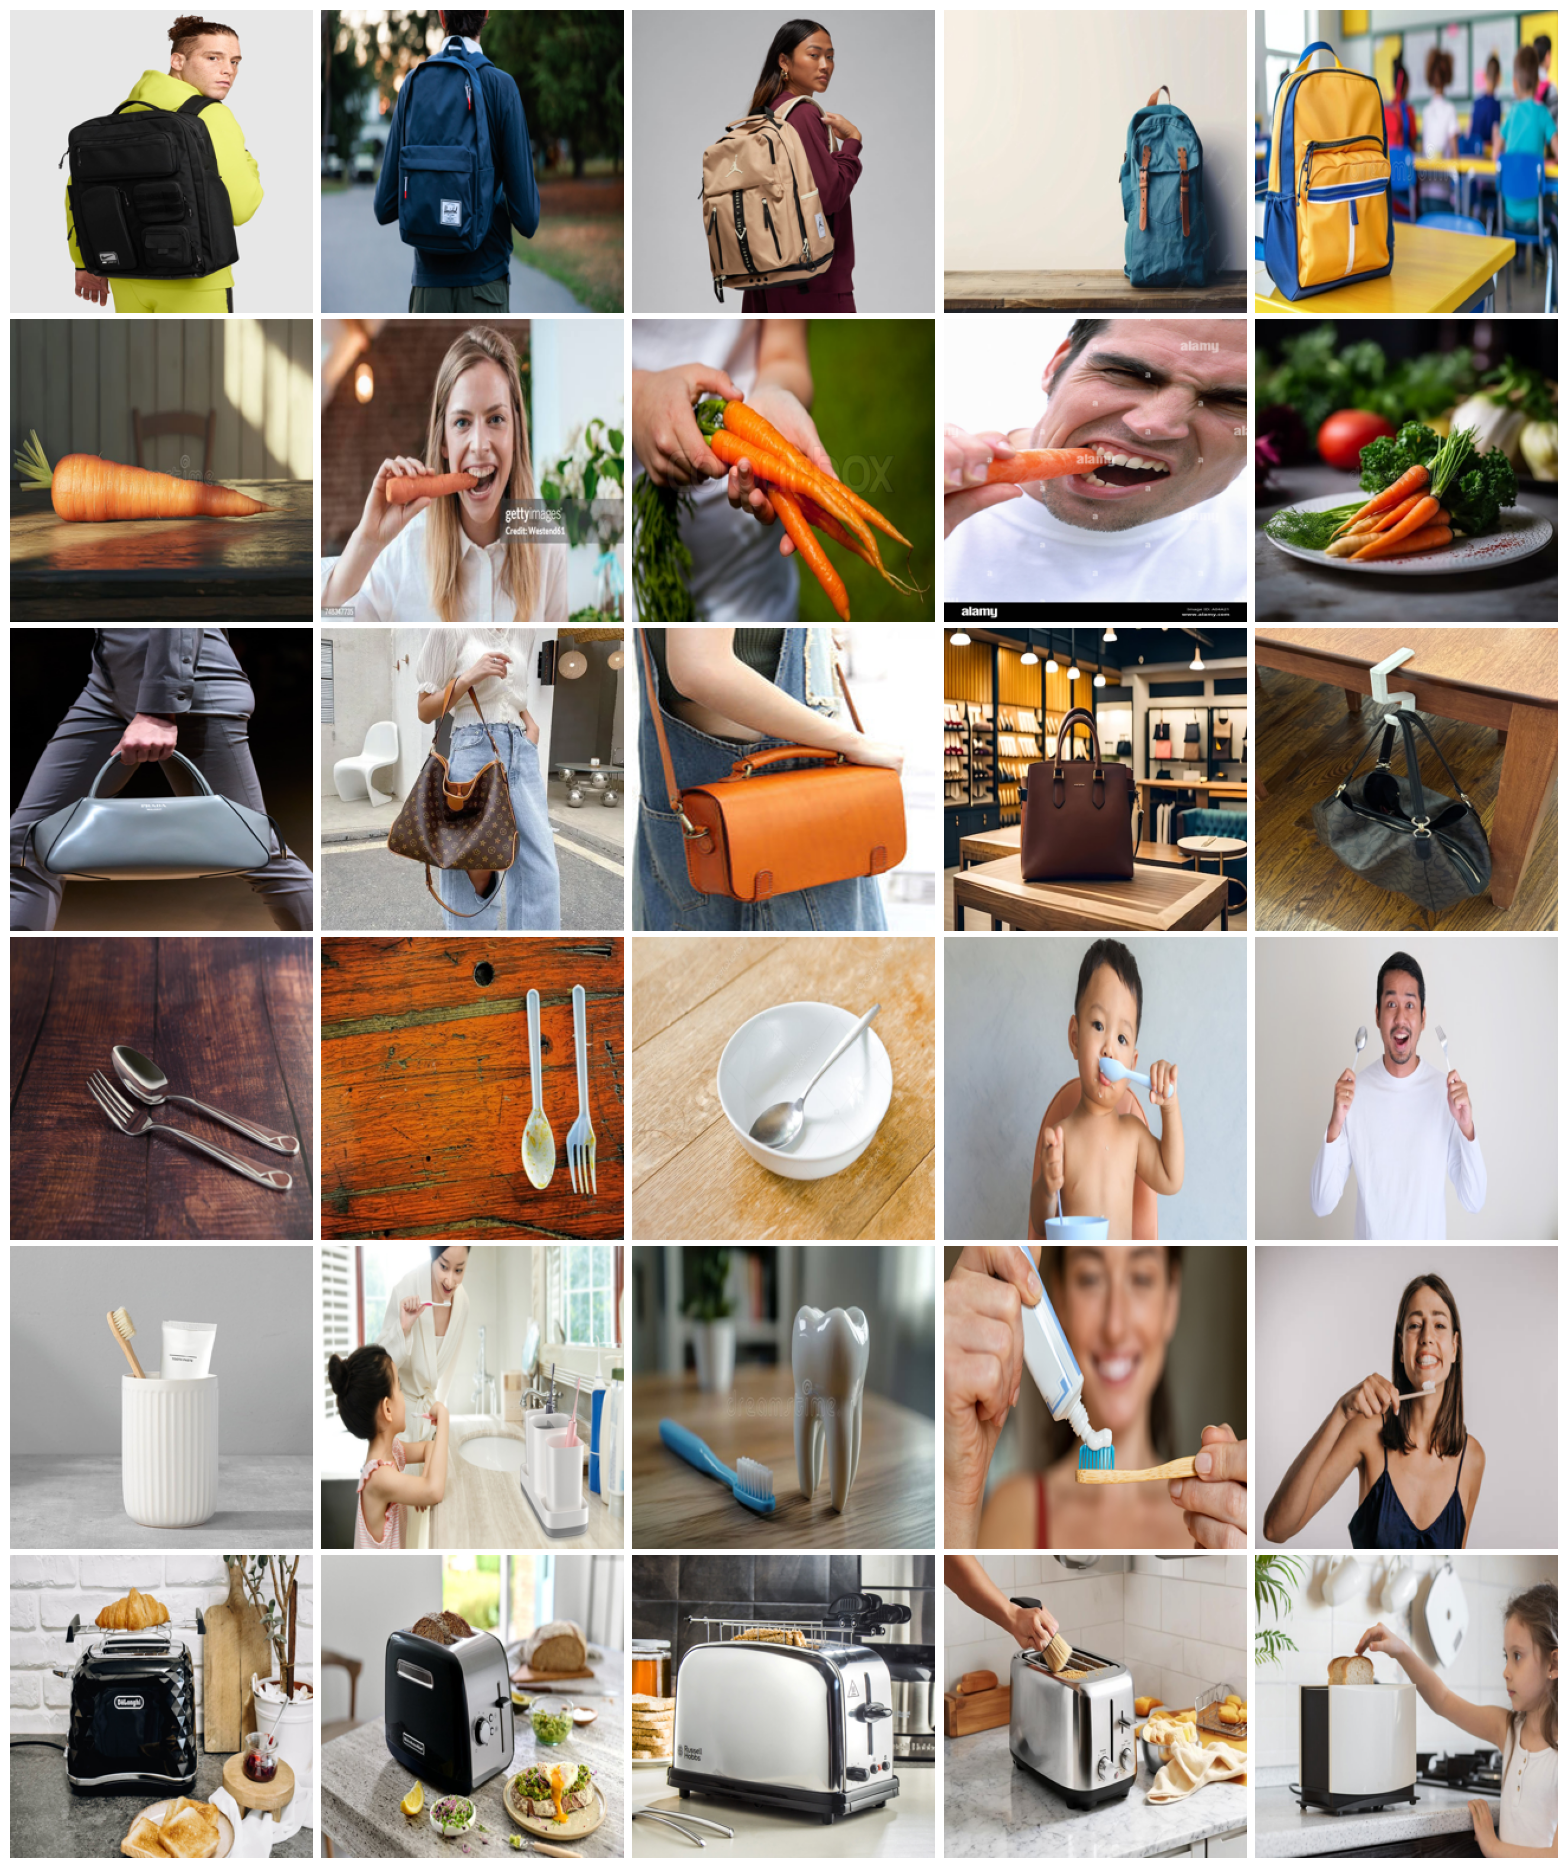

In [4]:
from PIL import Image
import matplotlib.pyplot as plt
import math

cols = 5
rows = math.ceil(len(diagnostic_files) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten()

for i, fname in enumerate(diagnostic_files):
    img = Image.open(os.path.join(diagnostic_dir, fname)).convert('RGB').resize((256, 256))
    axes[i].imshow(img)
    axes[i].axis('off')

for j in range(len(diagnostic_files), len(axes)):
    axes[j].axis('off')

plt.subplots_adjust(wspace=0.02, hspace=0.02)
plt.show()

In [5]:
results_for_audit = []

print(f"Generating captions for {len(diagnostic_files)} diagnostic images...")

with torch.no_grad():
    for filename in diagnostic_files:
        fpath = os.path.join(diagnostic_dir, filename)
        
        # Inference using beam search (k=5)
        seq, _ = caption_image_beam_search(encoder, decoder, fpath, word_map, 5)
        
        # Decode
        caption_tokens = [rev_word_map[i] for i in seq if i not in 
                          {word_map['<start>'], word_map['<end>'], word_map['<pad>']}]
        caption = " ".join(caption_tokens)
        
        results_for_audit.append({
            "filename": filename,
            "generated_caption": caption,
            "category": "",
            "comment": ""
        })

df_audit = pd.DataFrame(results_for_audit)
df_audit.to_csv("exp_4_hallucination_analysis_raw.csv", index=False)

print("\nDONE. Results saved to 'hallucination_analysis_raw.csv'.")
display(df_audit)

Generating captions for 30 diagnostic images...

DONE. Results saved to 'hallucination_analysis_raw.csv'.


,filename,generated_caption,category,comment
0,backpack1.jpg,a man in a yellow vest is holding a suitcase,,
1,backpack2.jpg,a man carrying a backpack and a backpack,,
2,backpack3.jpg,a woman holding a cell phone in her hand,,
3,backpack4.jpg,a blue bag with a blue backpack on it,,
4,backpack5.jpg,a yellow suitcase sitting on a wooden floor,,
5,carrot1.jpg,a carrot that is sitting on a table,,
6,carrot2.jpg,a woman holding a donut in her mouth,,
7,carrot3.jpg,a person cutting carrots on a cutting board,,
8,carrot4.jpg,a close up of a person eating a carrot,,
9,carrot5.jpg,a close up of a plate of food with broccoli,,


## Krok 3: Analiza wyników ręcznej anotacji

Wczytujemy wypełniony CSV i wizualizujemy rozkład kategorii błędów.

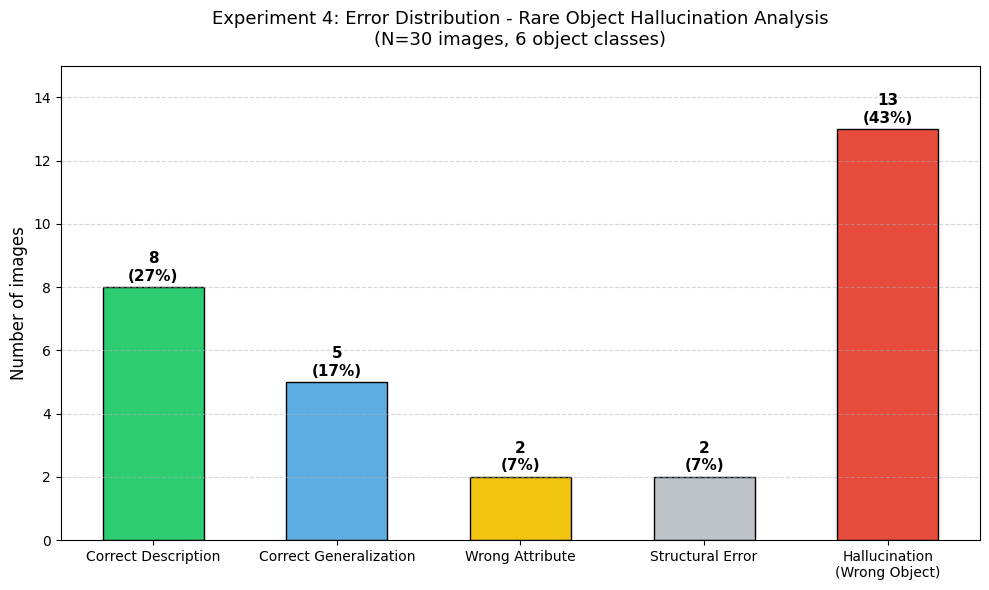

In [7]:
import matplotlib.pyplot as plt

df_results = pd.read_csv("exp_4_hallucination_analysis_raw.csv")

category_map = {
    'a': 'Hallucination\n(Wrong Object)',
    'b': 'Wrong Attribute',
    'c': 'Structural Error',
    'd': 'Correct Description',
    'e': 'Correct Generalization',
}

stats = df_results['category'].value_counts().reindex(['d', 'e', 'b', 'c', 'a'], fill_value=0)
plot_data = pd.DataFrame({
    'Description': [category_map[k] for k in stats.index],
    'Count': stats.values
})

plt.figure(figsize=(10, 6))
colors = ['#2ecc71', '#5dade2', '#f1c40f', '#bdc3c7', '#e74c3c']
bars = plt.bar(plot_data['Description'], plot_data['Count'], color=colors, width=0.55, edgecolor='black')

plt.title('Experiment 4: Error Distribution - Rare Object Hallucination Analysis\n(N=30 images, 6 object classes)', fontsize=13, pad=15)
plt.ylabel('Number of images', fontsize=12)
plt.ylim(0, max(plot_data['Count']) + 2)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    yval = bar.get_height()
    pct = yval / len(df_results) * 100
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.2,
             f'{int(yval)}\n({pct:.0f}%)', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

## Wnioski:

**Rozkład błędów (N=30 obrazów):**

| Kategoria | Liczba | % |
|-----------|--------|---|
| Halucynacja - zły obiekt (a) | 13 | 43% |
| Poprawny opis (d) | 8 | 27% |
| Poprawna generalizacja (e) | 5 | 17% |
| Błędny atrybut (b) | 2 | 7% |
| Błąd strukturalny (c) | 2 | 7% |

**Obserwacje per klasa:**

- **`toothbrush`** - 4/5 poprawnych opisów (d), 1 halucynacja.
  Najlepiej rozpoznawana klasa - charakterystyczny kształt i typowy
  kontekst (łazienka) ułatwiają klasyfikację.

- **`handbag`** - 4/5 poprawnych generalizacji (e): model opisuje torebkę
  jako `luggage` lub `purse`. Obiekt rozpoznany wizualnie poprawnie,
  brak pewności co do konkretnej podklasy torby.

- **`carrot`** - 2/5 poprawnych opisów (d), 2/5 halucynacji (a), 1 błędny
  atrybut (b). Model myli marchewkę z innymi warzywami lub słodyczami
  gdy kontekst sceny jest niejednoznaczny.

- **`backpack`** - wyniki mieszane: 1 halucynacja (a), 1 błędny atrybut (b),
  2 błędy strukturalne (c), 1 generalizacja (e).
  Model ma największy problem z tą klasą - brak dominującego wzorca błędu.

- **`spoon`** - 4/5 halucynacji (a): model generuje `scissors` zamiast łyżki.
  Nożyczki i łyżki mają podobny podłużny kształt, ale nożyczki są
  częstsze w COCO w kontekście pojedynczego obiektu na stole.

- **`toaster`** - 4/5 halucynacji (a): model generuje `microwave`, `oven`
  lub `grill`. Toster jest jednym z rzadszych obiektów COCO - zastępowany
  wizualnie podobnymi, lecz częstszymi urządzeniami AGD.